1. Create API call to extract gov data
Link to Austender Website: https://www.tenders.gov.au/Reports/CnPublishedForm


Website to read Json Format: https://jsonformatter.curiousconcept.com/

If json contains "next" under links. then this means the returned data from the API is not compelte. Another call needs to be made to the url in the next section to return the additional data, until there is no next section. Use this as a criteria to loop through and apply the function. 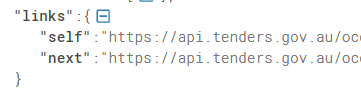

API Reference Data: https://github.com/austender/austender-ocds-api/tree/master

In [1]:
#Extracting the data from the API 

import requests
import json

start_date = '2026-06-01T00:00:00Z'
end_date = '2026-07-01T23:48:48Z'

url = f'https://api.tenders.gov.au/ocds/findByDates/contractPublished/{start_date}/{end_date}'

response = requests.get(url)
data = response.json()


In [8]:
for release in data['releases']:
    c = release.get('contracts',[])
    for item in c[0].get('items',[]):
        classification = item.get('classification',{})
        unspsc = classification.get('id')
        print(unspsc)

80160000
80160000
80160000
80160000
43200000
81112100
86000000
55110000
80111700
43230000
78111807
80111600
80111600
80141607
80111600
43200000
80170000
80111600
84111500
92121504
43210000
80100000
80100000
81111508
80111600
82111900
80120000
83120000
80111600
80120000
78131800
81112200
78111808
78111808
80111600
47110000
40150000
25170000
45130000
26100000
55110000
25170000
24110000
25100000
41100000
40100000
31200000
43230000
25130000
46180000
53102700
81112201
86000000
86000000
86000000
43230000
40150000
40140000
86000000
25180000
92111700
43210000
25132000
25111900
25101900
25100000
25111700
86000000
40140000
48100000
43230000
43230000
31270000
43210000
43210000
43210000
78140000
25111900
25111900
50000000
24110000
25111900
31330000
26110000
43210000
81112201
12350000
25100000
25110000
86000000
25100000
31160000
25100000
25100000
25111900
51000000
92120000
43210000
25111900
43210000


In [10]:
#Create a flat file for the dataframe

import pandas as pd
rows = []

for release in data['releases']:
    ocid = release.get('ocid')
    tender = release.get('tender',{})

    procurement_method = tender.get('procurementMethod')

    # Parties (supplier + procuring entity)
    parties = release.get('parties',[])

    # Awards (supplier info lives here too)
    awards = release.get('awards',[])

    # Contracts (value, UNSPSC, dates)
    contracts = release.get('contracts',[])

    for contract in contracts:
        contract_id = contract.get('id')
        contract_title = contract.get('title')
        contract_description = contract.get('description')

        #Contract Amounts
        value = contract.get('value',{})
        amount = value.get('amount')
        currency = value.get('currency')

        #Periods
        period = contract.get('period',{})
        start_date = period.get('startDate')
        end_date = period.get('endDate')

        #UNSPSC classification
        unspsc = None
        items = contract.get('items',[])
        for item in items:
            classification = item.get('classification',{})
            unspsc = classification.get('id')
            break

        

    


        #government agencies default
        agency_name = None
       

        for p in parties:
            roles = p.get('roles',[])
            if 'procuringEntity' in roles:
                agency_name = p.get('name')
                break



        
        #Suppliers
        supplier_name = None
        supplier_abn = None
        locality = None
        region = None
        postal = None
        country = None

        if awards:
            suppliers = awards[0].get('suppliers',[])
            if suppliers:
                supplier_name = suppliers[0].get('name')

                for p in parties:
                    if p.get('name') == supplier_name:
                        address = p.get('address',{})
                        locality = address.get('locality')
                        region = address.get('region')
                        postal = address.get('postalCode')
                        country = address.get('countryName')
                        break


        rows.append({
            'ocid':ocid,
            'contract_id':contract_id,
            'contract_title':contract_title,
            'contract_description':contract_description,
            'supplier_name':supplier_name,
            'unspsc':unspsc,
            'amount':amount,
            'start_date':start_date,
            'end_date':end_date,
            'locality':locality,
            'region':region,
            'postal':postal,
            'country':country,
            'procurement_method':procurement_method,
            'agency_name':agency_name
            })


df = pd.DataFrame(rows)
df

,ocid,contract_id,contract_title,contract_description,supplier_name,unspsc,amount,start_date,end_date,locality,region,postal,country,procurement_method,agency_name
0,prod-4cc2dd23d71c4d608f9b0bd69bf3c79c,CN4256645,NCD11719,Business administration services,Castledine Legal and Mediation Services,80160000,40000.00,2026-06-30T14:00:00Z,2028-12-30T13:00:00Z,Perth,WA,6000,AUSTRALIA,open,National Indigenous Australians Agency
1,prod-e3f52c66ca424d05bd5aaf27562d700d,CN4256642,NCD11697,Business administration services,Julie Walker,80160000,40000.00,2026-06-30T14:00:00Z,2028-12-30T13:00:00Z,Myocum,NSW,2481,AUSTRALIA,open,National Indigenous Australians Agency
2,prod-86883a7f1f374b5ea35f5839ab5ab266,CN4256639,NCD11689,Business administration services,Anthony Smith,80160000,40000.00,2026-06-30T14:00:00Z,2028-12-30T13:00:00Z,Byron Bay,NSW,2478,AUSTRALIA,open,National Indigenous Australians Agency
3,prod-f99e60bc0b664bf3b5aaa98274e89302,CN4256638,NCD11713,Business administration services,OneResolve,80160000,40000.00,2026-06-30T14:00:00Z,2028-12-30T13:00:00Z,Kiama,NSW,2533,AUSTRALIA,limited,National Indigenous Australians Agency
4,prod-42c8be48319b46b58aed32874eb9c0ce,CN4256628,4500180393,20x Dell Laptops for SWA,DEP OF EMPLOYMENT AND WORKPLACE REL,43200000,62900.00,2026-06-02T14:00:00Z,2026-06-29T14:00:00Z,CANBERRA,ACT,2601,AUSTRALIA,limited,Safe Work Australia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,prod-46ac5df123e94cabbcda46c99c1e56c0,CN4256507,3000679606,Pathology Products,BIOMERIEUX AUSTRALIA PTY LTD,51000000,16033.60,2026-06-28T14:00:00Z,2026-07-29T14:00:00Z,NORTH RYDE,NSW,2113,AUSTRALIA,limited,Department of Defence
96,prod-6cc49885e9d74574932d674fc1cc350a,CN4256504,3000680135,Security Services,SPOTLESS FACILITY SERVICES PTY LTD,92120000,36759.89,2025-10-12T13:00:00Z,2025-12-17T13:00:00Z,BRISBANE,QLD,4000,AUSTRALIA,limited,Department of Defence
97,prod-aae05276de86486bb26dd84a1dd8bcdb,CN4256505,3000679921,ICT Equipment,HP PPS AUSTRALIA PTY LTD,43210000,89716.00,2026-06-28T14:00:00Z,2026-12-13T13:00:00Z,RHODES,NSW,2138,AUSTRALIA,open,Department of Defence
98,prod-201288faf94e4f8aa5a2febb7b36a32e,CN4256502,3000680161,Ship Parts,SOFRACO ENGINEERING SYSTEMS PTY LTD,25111900,11526.03,2026-06-28T14:00:00Z,2026-08-16T14:00:00Z,ALEXANDRIA,NSW,2015,AUSTRALIA,limited,Department of Defence


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ocid                  100 non-null    object
 1   contract_id           100 non-null    object
 2   contract_title        99 non-null     object
 3   contract_description  100 non-null    object
 4   supplier_name         100 non-null    object
 5   unspsc                0 non-null      object
 6   amount                100 non-null    object
 7   start_date            100 non-null    object
 8   end_date              100 non-null    object
 9   locality              100 non-null    object
 10  region                100 non-null    object
 11  postal                100 non-null    object
 12  country               100 non-null    object
 13  procurement_method    100 non-null    object
 14  agency                100 non-null    object
dtypes: object(15)
memory usage: 11.8+ KB


In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')



In [10]:
df['amount'] = pd.to_numeric(df['amount'],errors='coerce')

In [39]:
df

,Agency,CN ID,SON ID,Supplier Name,Supplier ABN,Description,Category,Agency Ref. ID,Publish Date,Start Date,End Date,Value (AUD)
0,Australian Centre for International Agricultur...,CN4253780,NaN,Grace Records Management Aust Pty Ltd,93097110257,Records Management Storage,Management information systems MIS,C005737,2026-06-25 13:38:40,2026-07-01,2029-06-30,26400
1,Australian Centre for International Agricultur...,CN4253972,SON4228134,DATA#3 Limited,31010545267,VSA6 - Microsoft Licensing Software,Components for information technology or broad...,C005798,2026-06-25 14:57:33,2026-07-01,2031-06-30,650152
2,Australian Centre for International Agricultur...,CN4253974,SON4228134,DATA#3 Limited,31010545267,VSA6 - CRM Microsoft Licensing Software,Components for information technology or broad...,C005799,2026-06-25 15:15:10,2026-07-01,2031-06-30,169492
3,Australian Criminal Intelligence Commission,CN4253989,SON4102906,Myndworks trading as SKILL'D People.,95129394010,Contracted Services,Temporary personnel services,0000004195,2026-06-25 15:47:19,2026-07-01,2027-06-30,355417
4,Australian Criminal Intelligence Commission,CN4254039,SON4102906,Myndworks trading as SKILL'D People.,95129394010,Contracted Services,Temporary personnel services,0000004196,2026-06-25 19:57:37,2026-07-01,2027-06-30,335107
...,...,...,...,...,...,...,...,...,...,...,...,...
342,Office of the Director of Public Prosecutions,CN4253975,NaN,Vikrant Chaudhri,29235335988,Marine expert report,Legal services,G003259,2026-06-25 15:22:35,2026-06-10,2026-07-11,25000
343,Office of the Director of Public Prosecutions,CN4253991,NaN,Clare O'Connor,56181395947,Engagement of prosecution counsel,Legal services,N009417,2026-06-25 16:05:31,2026-05-27,2036-05-26,10000
344,Office of the Director of Public Prosecutions,CN4254032,NaN,Duncan James Berents,54822497228,Engagement of prosecution counsel,Legal services,N009510,2026-06-25 16:56:01,2026-06-25,2036-06-24,48400
345,Office of the Director of Public Prosecutions,CN4254035,SON3965020,Hudson Global Resources (Aust) Pty Limited,21002888762,LSO Perth,Temporary personnel services,G003263,2026-06-25 17:16:52,2026-07-03,2026-10-02,34359


In [40]:
agency_df = df.groupby('Agency').agg({'Value (AUD)':'sum'})
agency_df

,Value (AUD)
Agency,
Australian Centre for International Agricultural Research,846044
Australian Criminal Intelligence Commission,690524
Australian Maritime Safety Authority,617678
Australian Pesticides and Veterinary Medicines Authority,9434488
"Department of Climate Change, Energy, the Environment and Water",2252951
Department of Defence,54191722
Department of Education,18545163
Department of Employment and Workplace Relations,1469813
Department of Finance,2160261


In [42]:
supplier_df = df.groupby('Supplier Name').agg({'Value (AUD)':'sum'})
supplier_df

,Value (AUD)
Supplier Name,
"A.M.T. MARICAN LTD.,PART.",90406
AEROBASE GROUP INC,69763
AGILENT TECHNOLOGIES AUSTRALIA PTY LTD,32992
APOLLO TECHNOLOGY PTY LTD,15726
APRICOT ZEBRA PTY LTD,75075
...,...
YMCA Australia,21802
Zenith Media; a division of Publicis Media Australia Pty Ltd,189000000
[AUD] Scantechnics Pty Ltd,15322


In [51]:
category_df = df.groupby(['Category','Supplier Name'], as_index=False).agg(
    total = ('Value (AUD)','sum'),
    average = ('Value (AUD)','mean'))
category_df

,Category,Supplier Name,total,average
0,Adhesives and sealants,MILSPEC SERVICES PTY LIMITED,13640,13640.0
1,Advertising,Zenith Media; a division of Publicis Media Aus...,189000000,189000000.0
2,Aerospace systems and components and equipment,MILSPEC SERVICES PTY LIMITED,55974,27987.0
3,Air transportation support systems and equipment,EUROCONTROLORGANISATION EUROPEENNE POUR LA SEC...,16332,16332.0
4,Aircraft equipment,MILSPEC SERVICES PTY LIMITED,10003,10003.0
...,...,...,...,...
250,Vehicle maintenance and repair services,HAULMARK TRAILERS (AUSTRALIA) PTY LTD,63117,31558.5
251,Vehicle maintenance and repair services,R.G.M. MAINTENANCE PTY LTD,67911,33955.5
252,Vehicle maintenance and repair services,RHEINMETALL MAN MILITARY VEHICLES AUSTRALIA PT...,126559,63279.5
253,War vehicles,THALES AUSTRALIA,138640,69320.0


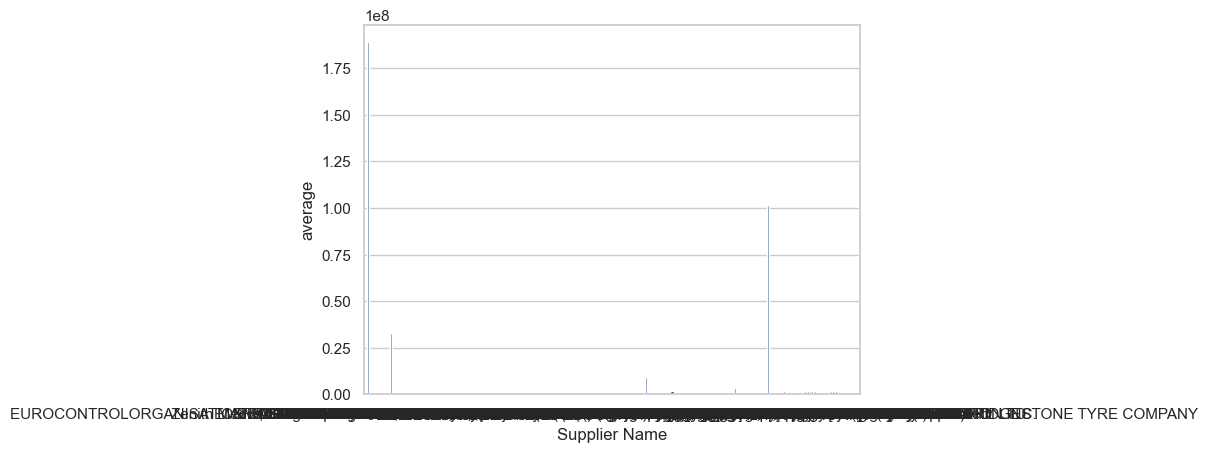

In [57]:
sns.barplot(data=category_df,x='Supplier Name',y='average')
plt.show()